# Car Price Analysis Project
## Machine Learning Assignment 1

**Import libraries**

In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [209]:
df = pd.read_csv("car_price.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


# Task 1: Exploratory Data Analysis

In [210]:
# shape of dataset (How many rows and columns does the dataset have?)

df.shape

(72435, 10)

In [211]:
#  Data Types and

df.dtypes

,0
model,object
year,float64
price,float64
transmission,object
mileage,float64
fuelType,object
tax,float64
mpg,float64
engineSize,float64
Make,object


In [212]:
#  Feature Classification (Which features are numerical? Which are categorical? )

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns
print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize'], dtype='object')
Categorical Columns: Index(['model', 'transmission', 'fuelType', 'Make'], dtype='object')


In [213]:
#Missing Values (Are there any missing values? How many, and in which columns?)

df.isnull().sum()

,0
model,3621
year,3622
price,3621
transmission,3623
mileage,3622
fuelType,3622
tax,3621
mpg,3621
engineSize,3622
Make,3621


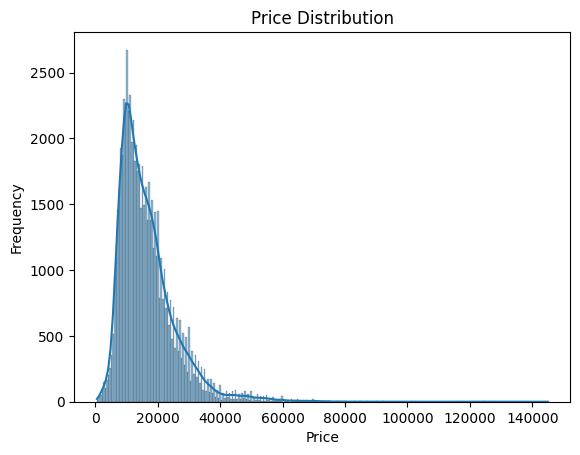

count     68814.000000
mean      16583.919261
std        9304.412707
min         495.000000
25%       10167.250000
50%       14495.000000
75%       20359.750000
max      145000.000000
Name: price, dtype: float64


In [214]:
#Price Distribution ( What does the distribution of car prices look like? )

sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

print(df['price'].describe())

The distribution is right-skewed, meaning most cars are low-priced with few expensive ones

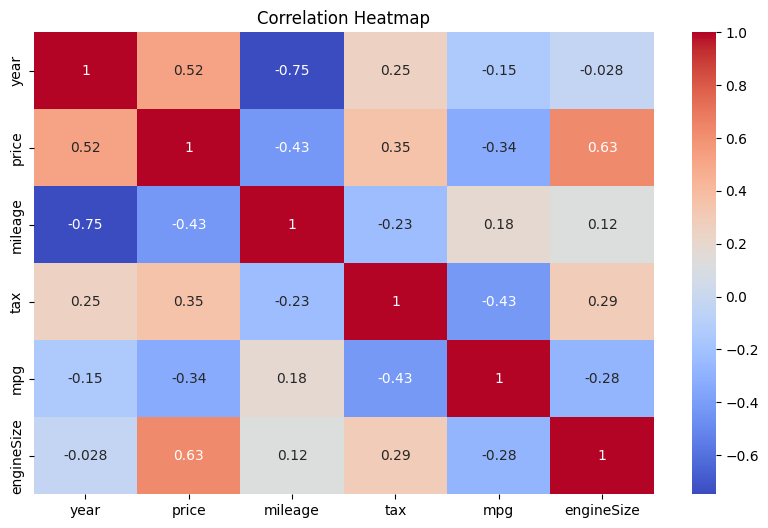

In [215]:
# Correlation Between Features (Which features seem most related to price? )

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [216]:
corr['price'].sort_values(ascending=False)

,price
price,1.000000
engineSize,0.629839
year,0.519383
tax,0.353204
mpg,-0.335615
mileage,-0.427524


The most positively correlated features are: engineSize, year

The most negatively correlated features are: mileage, mpg

 ### Relationship Between Price and Important Features

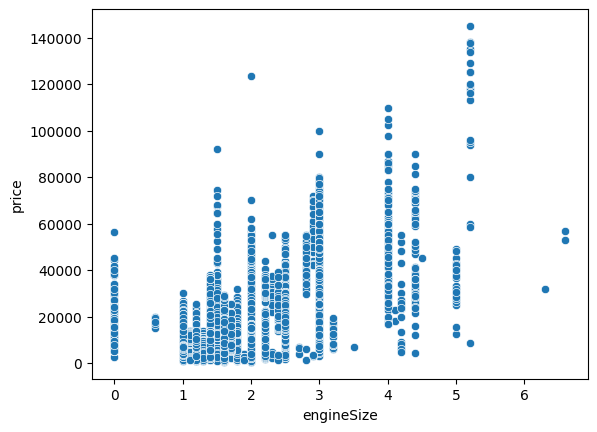

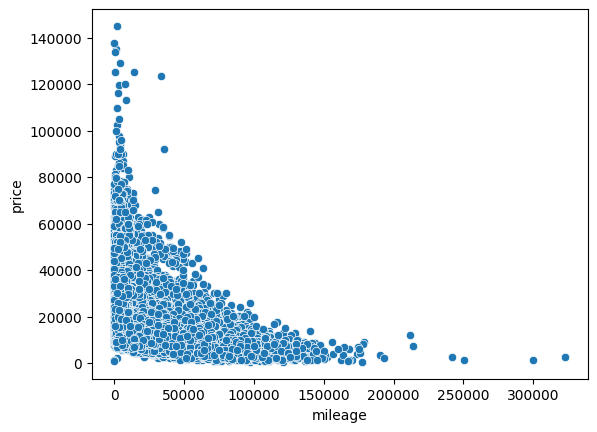

In [217]:
# numerical (most related)
sns.scatterplot(x=df['engineSize'], y=df['price'])
plt.show()

sns.scatterplot(x=df['mileage'], y=df['price'])
plt.show()

In [218]:
#categorical
print(df.groupby('model')['price'].mean().sort_values(ascending=False))
print("------------")
print(df.groupby('Make')['price'].mean().sort_values(ascending=False))
print("------------")
print(df.groupby('fuelType')['price'].mean().sort_values(ascending=False))
print("------------")
print(df.groupby('transmission')['price'].mean().sort_values(ascending=False))

model
R8            97257.080000
X7            69878.187500
8 Series      64424.875000
Q8            59598.133333
California    57565.500000
                  ...     
Getz           1927.500000
Streetka       1924.500000
Amica          1750.000000
Fox            1733.500000
Accent         1295.000000
Name: price, Length: 145, dtype: float64
------------
Make
audi       22894.679872
BMW        22727.820273
vw         16837.325011
skoda      14292.749382
Hyundai    12806.737070
toyota     12504.774279
Ford       12279.505885
Name: price, dtype: float64
------------
fuelType
Hybrid      19067.922073
Diesel      18885.788116
Other       17414.302885
Electric    17374.600000
Petrol      14743.939671
Name: price, dtype: float64
------------
transmission
Semi-Auto    23493.355456
Automatic    21373.580206
Other        14571.000000
Manual       12543.124548
Name: price, dtype: float64


Based on the analysis of both categorical features (groupby mean) and numerical features (correlation matrix), we can conclude the following :

engineSize (strong positive correlation: 0.63)

year (moderate positive correlation: 0.52)

mileage (moderate negative correlation: -0.43)

model (very strong variation in average price across different car models)

transmission (large differences in average price across categories)

Make (strong variation in average price between brands)


 Overall, engineSize,model, transmission, and Make show the strongest relationship with price, followed by year and mileage.

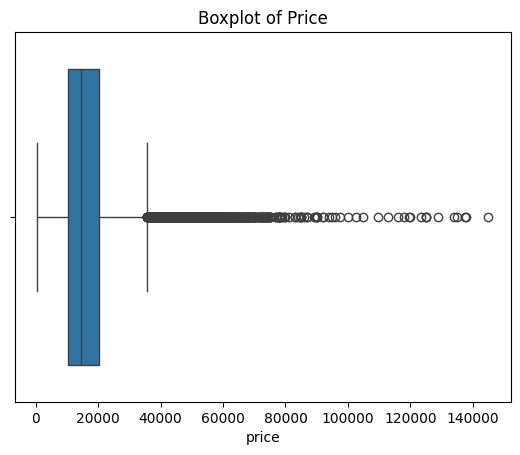

In [219]:
#Outlier Detection

sns.boxplot(x=df['price'])
plt.title("Boxplot of Price")
plt.show()

# Task 2 : Data Preprocessing

**step 0 : Train & Test Split**

We split the data **before any preprocessing** to prevent data leakage.
Data leakage means the model sees test data during training, which gives fake good results.
All preprocessing steps will be fit on train only, then applied to test using the same values.

In [220]:
# Drop rows where price is missing before splitting (no target = useless row)
df_model = df.dropna(subset=['price']).copy()

train, test = train_test_split(df_model, test_size=0.2, random_state=1)

print(f'Train: {train.shape}')
print(f'Test: {test.shape}')

Train: (55051, 10)
Test: (13763, 10)


In [221]:
train_clean = train.copy()
test_clean  = test.copy()

**step 1 : Handling missing values**
1. Before splitting, rows with missing values in the target variable (price) were dropped, since the model cannot be trained without a target value
2. Numerical features (year, mileage, tax, mpg, engineSize) were filled using the median calculated from the training data, as it is more robust to outliers
3. Categorical features (transmission, fuelType, Make) were filled using the mode from the training set
    - Text normalization was applied to categorical features by removing extra spaces and converting all values to lowercase
4. Next, we fill missing values in 'model' using group-wise imputation:
    - for each 'Make', we fill with the most frequent 'model' in that group
        - Missing values in the model column were handled using group-wise imputation:
            * For each Make, missing model values were filled with the most frequent model within that group (calculated from the training data).
            * For the test set, the same mapping from the training data was applied.

In [222]:
# Compute median from train only, apply to both
numerical_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
for col in numerical_cols:
    train_median = train_clean[col].median()
    train_clean[col]= train_clean[col].fillna(train_median)
    test_clean[col]= test_clean[col].fillna(train_median)

In [223]:
categorical_cols = ['transmission', 'fuelType', 'Make']
for col in categorical_cols:
    train_mode = train_clean[col].mode()[0]
    train_clean[col] = train_clean[col].fillna(train_mode)
    test_clean[col]  = test_clean[col].fillna(train_mode)
    # normalize text
    train_clean[col] = train_clean[col].str.strip().str.lower()
    test_clean[col]  = test_clean[col].str.strip().str.lower()

#Handeling nulls in model columns
# normalize text
train_clean['model'] = train_clean['model'].str.strip().str.lower()
test_clean['model']  = test_clean['model'].str.strip().str.lower()

# get mode per Make
model_mode_per_make = train_clean.groupby('Make')['model'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
)

# fill train
train_clean['model'] = train_clean.groupby('Make')['model'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)

# fill test
test_clean['model'] = test_clean['model'].fillna(
    test_clean['Make'].map(model_mode_per_make)
)

# fallback
train_clean['model'] = train_clean['model'].fillna('unknown')
test_clean['model']  = test_clean['model'].fillna('unknown')

train_clean.isnull().sum()
test_clean.isnull().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0
Make,0


**step 2 : Detect and handle outliers**

In [224]:
train_clean[numerical_cols].describe().round(2)

,year,mileage,tax,mpg,engineSize
count,55051.00,55051.00,55051.00,55051.00,55051.00
mean,2017.07,22953.76,118.31,55.85,1.63
std,2.05,20912.88,62.85,16.89,0.54
min,1996.00,1.00,0.00,0.30,0.00
25%,2016.00,7736.00,125.00,47.90,1.20
50%,2017.00,17554.50,145.00,55.40,1.60
75%,2019.00,31591.00,145.00,62.80,2.00
max,2020.00,323000.00,580.00,470.80,6.60


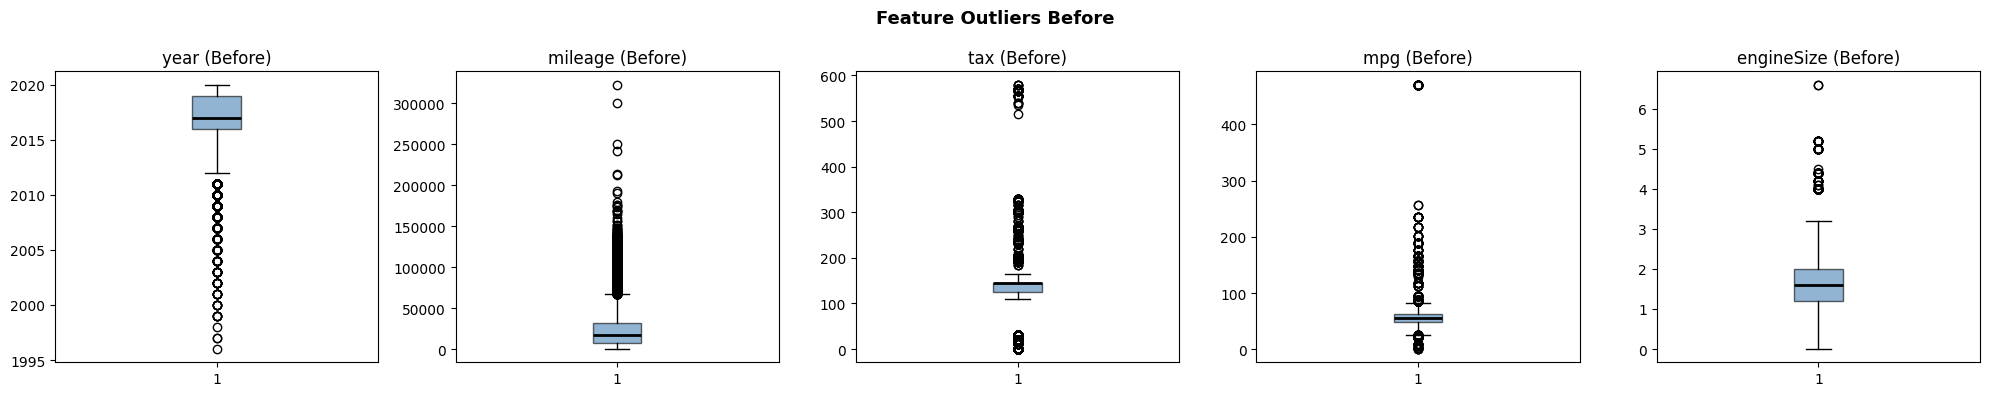

In [225]:
# Before handling
fig_feat, axes_feat = plt.subplots(1, 5, figsize=(20, 4))

for i, col in enumerate(numerical_cols):
    axes_feat[i].boxplot(train_clean[col], patch_artist=True,
                         boxprops=dict(facecolor='steelblue', alpha=0.6),
                         medianprops=dict(color='black', linewidth=2))
    axes_feat[i].set_title(f'{col} (Before)')

plt.suptitle('Feature Outliers Before', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [226]:
# Handling: IQR + Winsorization
for col in numerical_cols:
    Q1    = train_clean[col].quantile(0.25)
    Q3    = train_clean[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = train_clean[(train_clean[col] < lower) | (train_clean[col] > upper)]
    print(f'{col}: {len(outliers)} outliers bounds [{lower:.2f}, {upper:.2f}]')
    train_clean[col] = train_clean[col].clip(lower=lower, upper=upper)
    test_clean[col] = test_clean[col].clip(lower=lower, upper=upper)

year: 922 outliers bounds [2011.50, 2023.50]
mileage: 2445 outliers bounds [-28046.50, 67373.50]
tax: 15895 outliers bounds [95.00, 175.00]
mpg: 788 outliers bounds [25.55, 85.15]
engineSize: 241 outliers bounds [-0.00, 3.20]


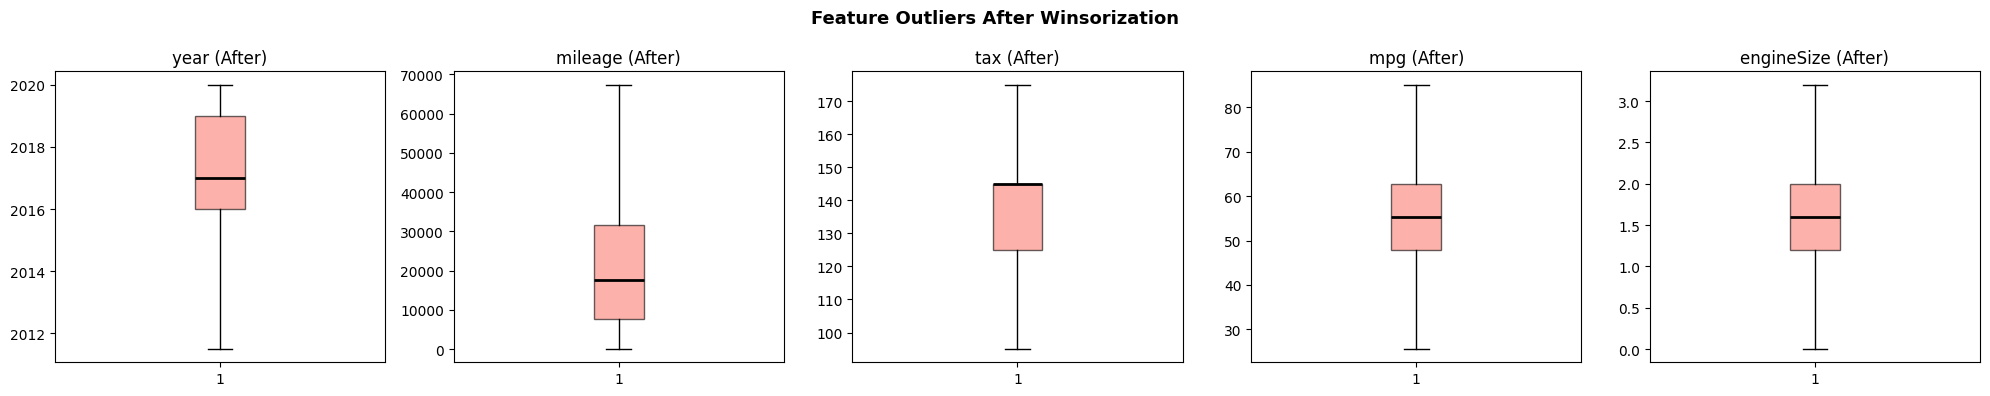

In [227]:
# After
fig_feat2, axes_feat2 = plt.subplots(1, 5, figsize=(20, 4))

for i, col in enumerate(numerical_cols):
    axes_feat2[i].boxplot(train_clean[col], patch_artist=True,
                          boxprops=dict(facecolor='salmon', alpha=0.6),
                          medianprops=dict(color='black', linewidth=2))
    axes_feat2[i].set_title(f'{col} (After)')

plt.suptitle('Feature Outliers After Winsorization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

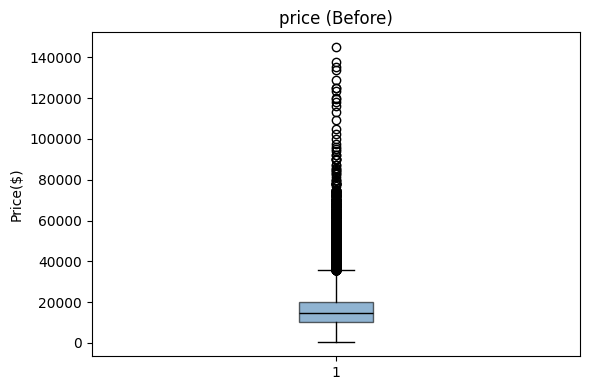

In [228]:
plt.figure(figsize=(6, 4))
plt.boxplot(train_clean['price'], patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6),
            medianprops=dict(color='black', linewidth=1))
plt.title('price (Before)')
plt.ylabel('Price($)')
plt.tight_layout()
plt.show()

**Inspect outliers in the target column (price)**

We check the price column separately since it is the target variable.
Outliers in the target distort what the model learns, so we inspect them before deciding how to handle them.

In [229]:
# Compute price bounds from train only
Q1    = train_clean['price'].quantile(0.25)
Q3    = train_clean['price'].quantile(0.75)
IQR   = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

price_outliers = train_clean[(train_clean['price'] < lower) | (train_clean['price'] > upper)]
print(f'Price Outliers : {len(price_outliers)}')

# We only drop from train.Test stays as it is (we never modify test labels)
length_before = len(train_clean)
train_clean = train_clean[(train_clean['price'] >= lower) & (train_clean['price'] <= upper)]
print(f'Rows dropped: {length_before - len(train_clean)}')
print(f'Rows after  : {len(train_clean)}')

Price Outliers : 2035
Rows dropped: 2035
Rows after  : 53016


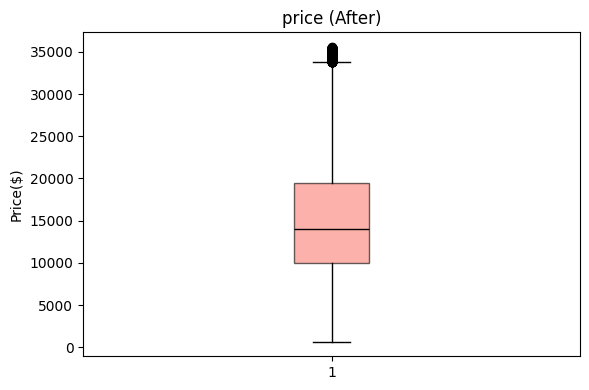

In [230]:
plt.figure(figsize=(6, 4))
plt.boxplot(train_clean['price'], patch_artist=True,
            boxprops=dict(facecolor='salmon', alpha=0.6),
            medianprops=dict(color='black', linewidth=1))
plt.title('price (After)')
plt.ylabel('Price($)')
plt.tight_layout()
plt.show()

**step 3 : Encoding Categorical columns**

In [231]:
cat_cols_to_encode = ['model', 'transmission', 'fuelType', 'Make']

for col in cat_cols_to_encode:
    print(f"{col}: {train_clean[col].nunique()}")

model: 135
transmission: 4
fuelType: 5
Make: 7


**Label Encoding :**
Label Encoding was applied to the high-cardinality feature 'model' with additional handling for unseen values

In [232]:
le = LabelEncoder()
# fit train
train_clean['model'] = le.fit_transform(train_clean['model'])
# handle unseen values in test
test_clean['model'] = test_clean['model'].apply(
    lambda x: x if x in le.classes_ else 'unknown'
)
# add 'unknown' to classes
le.classes_ = np.append(le.classes_, 'unknown')
# transform test
test_clean['model'] = le.transform(test_clean['model'])
train_clean.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
70471,51,2017.0,7169.0,manual,18610.0,petrol,145.0,57.7,1.2,hyundai
58577,21,2017.0,6388.0,manual,26850.0,petrol,95.0,69.0,1.0,toyota
8373,11,2015.0,13650.0,manual,37314.0,diesel,145.0,55.4,2.0,audi
11672,124,2017.0,18698.0,semi-auto,41384.0,diesel,145.0,55.4,2.0,bmw
20801,1,2017.0,13000.0,manual,28706.0,petrol,125.0,52.3,1.5,bmw


**One-Hot Encoding :**

We use One-Hot Encoding for 'transmission', 'fuelType', and 'Make', because they have a small number of categories and no natural order.

In [233]:
cat_cols = ['transmission', 'fuelType', 'Make']
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# fit train
train_ohe = ohe.fit_transform(train_clean[cat_cols])
# transform test
test_ohe = ohe.transform(test_clean[cat_cols])

ohe_cols = ohe.get_feature_names_out(cat_cols)
train_ohe_df = pd.DataFrame(train_ohe, columns=ohe_cols, index=train_clean.index)
test_ohe_df  = pd.DataFrame(test_ohe, columns=ohe_cols, index=test_clean.index)

# drop original categorical columns
train_clean = train_clean.drop(columns=cat_cols)
test_clean  = test_clean.drop(columns=cat_cols)
# concat new encoded columns
train_clean = pd.concat([train_clean, train_ohe_df], axis=1)
test_clean  = pd.concat([test_clean, test_ohe_df], axis=1)
train_clean.head()

,model,year,price,mileage,tax,mpg,engineSize,transmission_automatic,transmission_manual,transmission_other,...,fuelType_hybrid,fuelType_other,fuelType_petrol,Make_audi,Make_bmw,Make_ford,Make_hyundai,Make_skoda,Make_toyota,Make_vw
70471,51,2017.0,7169.0,18610.0,145.0,57.7,1.2,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
58577,21,2017.0,6388.0,26850.0,95.0,69.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8373,11,2015.0,13650.0,37314.0,145.0,55.4,2.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
11672,124,2017.0,18698.0,41384.0,145.0,55.4,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
20801,1,2017.0,13000.0,28706.0,125.0,52.3,1.5,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


**step 4 : Scale numerical features**

**We apply StandardScaler to numerical features: (year, mileage, tax, mpg, engineSize, model)**, because KNN depends on distance calculations

In [234]:
# Fit on train only, apply to both
scale_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'model']
scaler     = StandardScaler()

train_clean[scale_cols] = scaler.fit_transform(train_clean[scale_cols])
test_clean[scale_cols] = scaler.transform(test_clean[scale_cols])

print('Train After scaling:')
print(train_clean[scale_cols].describe().round(2))

Train After scaling:
           year   mileage       tax       mpg  engineSize     model
count  53016.00  53016.00  53016.00  53016.00    53016.00  53016.00
mean      -0.00      0.00      0.00      0.00        0.00     -0.00
std        1.00      1.00      1.00      1.00        1.00      1.00
min       -3.03     -1.25     -1.61     -2.83       -3.31     -1.40
25%       -0.57     -0.79     -1.61     -0.67       -0.81     -0.78
50%       -0.03     -0.28      0.48     -0.05        0.03     -0.23
75%        1.06      0.53      0.48      0.64        0.86      0.65
max        1.61      2.47      1.73      2.72        3.36      2.08


## Preprocessing Summary

| Step               | Action                                                                                                                                                                                                                                                   | Why                                                                                                                                          |
|--------------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|----------------------------------------------------------------------------------------------------------------------------------------------|
| **Split**          | 80% train, 20% test after dropping missing target values                                                                                                                                                                                                 | Ensures valid training data and prevents data leakage                                    |
| **Missing Values** | Drop rows with missing price before split; fill categorical features (Make, transmission, fuelType) with Mode; fill model using group-wise imputation (per Make); fill numerical features with Median; apply fallback value for remaining missing values | All statistics computed from train only, then applied to test to avoid data leakage |
| **Outliers**       | Apply IQR-based Winsorization on feature columns using bounds from train; remove outliers in price from train only                                                                                                                                       | Prevents extreme values from affecting the model while preserving test data integrity                                  |
| **Encoding**       | Apply Label Encoding to model with handling for unseen values & One-Hot for transmission, fuelType, Make                                                                                     | Label Encoding avoids high dimensionality for model, while One-Hot Encoding preserves category independence for low-cardinality features                                            |
| **Scaling**        | Apply StandardScaler to numerical columns (year, mileage, tax, mpg, engineSize, model); exclude price                                                                                                                                                    | Normalizes feature scales to improve model performance; fitted on train only                                     |

## Task 3 : Create Two Target Variables

A. Regression Target (Linear Regression)



In [235]:
x_train = train_clean.drop(columns=['price'])
y_train = train_clean['price']

x_test  = test_clean.drop(columns=['price'])
y_test  = test_clean['price']

print(f'x_train : {x_train.shape}')
print(f'x_test  : {x_test.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_test  : {y_test.shape}')

x_train : (53016, 22)
x_test  : (13763, 22)
y_train : (53016,)
y_test  : (13763,)


B. Classification Target (KNN)

In [236]:
# divide data to three categorical (cheap, Moderate, Expensive)
low_threshold = train_clean['price'].quantile(0.33)
high_threshold = train_clean['price'].quantile(0.66)

conditions = [
    train_clean['price'] <= low_threshold,
    train_clean['price'] >= high_threshold
]

choices = ['cheap', 'expensive']

train_clean['price_cat'] = np.select(conditions, choices, default='moderate')

train_clean['price_cat'].value_counts()

#show original data
train_clean.head()


,model,year,price,mileage,tax,mpg,engineSize,transmission_automatic,transmission_manual,transmission_other,...,fuelType_other,fuelType_petrol,Make_audi,Make_bmw,Make_ford,Make_hyundai,Make_skoda,Make_toyota,Make_vw,price_cat
70471,-0.077282,-0.028732,7169.0,-0.223458,0.477991,0.168098,-0.806297,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,cheap
58577,-0.857117,-0.028732,6388.0,0.232110,-1.611468,1.220318,-1.223170,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,cheap
8373,-1.117062,-1.119313,13650.0,0.810637,0.477991,-0.046070,0.861197,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,moderate
11672,1.820317,-0.028732,18698.0,1.035657,0.477991,-0.046070,0.861197,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,expensive
20801,-1.377007,-0.028732,13000.0,0.334724,-0.357793,-0.334732,-0.180986,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,moderate


Decide the thresholds (price boundaries) for each category & how many cars in each category:

In [237]:
print("Threshold 1 (Low): ",low_threshold)
print("Threshold 2 (High): ",high_threshold)

# show threshold for each category

print ("The price boundaries: \n" ,"any price lesser than " , low_threshold , " It is considered cheap")
print (" any price greater than " , high_threshold , " It is considered expensive")
print (" any price between " , high_threshold , " and " , low_threshold ," It is considered moderate \n")

# Show how many cars fall into each category after splitting.

print(train_clean['price_cat'].value_counts())

Threshold 1 (Low):  11057.0
Threshold 2 (High):  17450.0
The price boundaries: 
 any price lesser than  11057.0  It is considered cheap
 any price greater than  17450.0  It is considered expensive
 any price between  17450.0  and  11057.0  It is considered moderate 

price_cat
expensive    18042
cheap        17496
moderate     17478
Name: count, dtype: int64


Justify my thresholds — use the data distribution to support your decision

To define the thresholds for the price categories (Cheap, Moderate, and Expensive), I analyzed the price distribution using the percentiles (Quantiles) of the dataset. I chose the 33rd and 66th percentiles as my boundaries for the following reasons:

1.  Data Balance: Using quantiles ensures that each category contains approximately one-third of the total cars. This prevents the KNN model from being biased toward a specific class that might have more data than others (Class Imbalance problem).
2.  Statistical Evidence: Based on the EDA and the describe() function, the 33rd percentile represents the lower-end market, while the 66th percentile marks the transition to premium/high-end cars.
3.  Threshold Values: The calculated boundaries are:
* Cheap: Prices $\le$ 11125
* Moderate: Prices between 11125 and 17480
* Expensive: Prices $>$ 17480

# Task 4: Linear Regression Model
We will train a Linear Regression model to predict the car price.

In [238]:
#Training model
model = LinearRegression()
model.fit(x_train, y_train)
#prediction
y_pred = model.predict(x_test)

In [239]:
#Evaluation techniques
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2783.7792266365095
MSE: 21559162.481812563
RMSE: 4643.184519466415
R2 Score: 0.7481749926251329


## Model Evaluation:

R² = 0.748 → the model explains about 75% of the variance in car prices, which indicates a moderate to good fit.

MAE = 2783 → on average, the model's predictions are off by ±£2,783 from the actual price.

RMSE = 4643 → the typical prediction error is around £4,643. RMSE is higher than MAE because it penalizes large errors more heavily, which suggests there are some cases where the model makes significantly larger mistakes.

MSE = 21,559,162 → this is the squared version of the error, used mainly during model training. The large value is expected since prices are in the thousands.

Overall, the Linear Regression model performs reasonably well, but the gap between MAE and RMSE suggests the model struggles with some high-priced cars. A more complex model might improve performance.

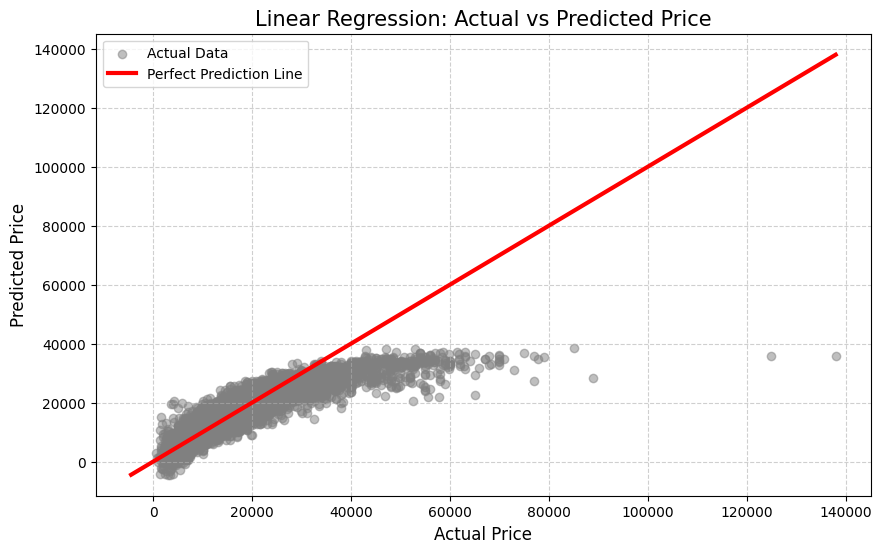

In [240]:
plt.figure(figsize=(10, 6))

# Plot actual vs predicted points
plt.scatter(y_test, y_pred, color='gray', alpha=0.5, label='Actual Data')

# line range (perfect prediction line)
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))

plt.plot(
    np.linspace(min_val, max_val, 100),
    np.linspace(min_val, max_val, 100),
    color='red',
    linewidth=3,
    label='Perfect Prediction Line'
)

plt.title('Linear Regression: Actual vs Predicted Price', fontsize=15)
plt.xlabel('Actual Price', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### Trying to improve R² by based on correlations (The most positively correlated features are: engineSize, year & The most negatively correlated features are: mileage, mpg)

In [241]:
# --- Age feature (based on year)
x_train['age'] = 2026 - x_train['year']
x_test['age']  = 2026 - x_test['year']

# --- Squared features
x_train['mileage_sq'] = x_train['mileage'] ** 2 # we can capture non-linear relationships with squared features
x_test['mileage_sq']  = x_test['mileage'] ** 2

x_train['engine_sq'] = x_train['engineSize'] ** 2
x_test['engine_sq']  = x_test['engineSize'] ** 2

x_train['age_sq'] = x_train['age'] ** 2
x_test['age_sq']  = x_test['age'] ** 2

# --- Interaction features
x_train['age_mileage'] = x_train['age'] * x_train['mileage'] #The most positively correlated features are: engineSize, year The most negatively correlated features are: mileage, mpg
x_test['age_mileage']  = x_test['age'] * x_test['mileage']

x_train['engine_mileage'] = x_train['engineSize'] * x_train['mileage']
x_test['engine_mileage']  = x_test['engineSize'] * x_test['mileage']

x_train['age_engine'] = x_train['age'] * x_train['engineSize']
x_test['age_engine']  = x_test['age'] * x_test['engineSize']

# --- Ratio features (important for regression)
x_train['mileage_per_engine'] = x_train['mileage'] / (x_train['engineSize'] + 1) # add 1 to avoid division by zero
x_test['mileage_per_engine']  = x_test['mileage'] / (x_test['engineSize'] + 1)

x_train['mileage_per_age'] = x_train['mileage'] / (x_train['age'] + 1)
x_test['mileage_per_age']  = x_test['mileage'] / (x_test['age'] + 1)

# Model
model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 2557.7951239031063
MSE: 17788877.070525642
RMSE: 4217.686222388485
R2: 0.7922143727403691


### R2 has increased from 74% to 79%

Explanation:

Based on correlation analysis, engine size and manufacturing year show a strong positive correlation with car price, indicating that newer cars with larger engines tend to have higher prices.

On the other hand, mileage and fuel efficiency (mpg) show a negative correlation with price, meaning that cars with higher usage and better fuel efficiency generally have lower prices or reflect different market segments.

Therefore, interaction features were created to capture hidden relationships between these variables, such as engine size with year, and mileage with mpg, in order to improve the model's ability to learn more complex patterns

# Task 5 : Model 2: KNN Classification


uses LabelEncoder from sklearn to convert categorical target values in the price_cat column (such as Cheap, Moderate, and Expensive) into numerical format.

Machine learning models cannot work directly with text labels, so LabelEncoder assigns each category a unique integer (for example: Cheap → 0, Moderate → 1, Expensive → 2). The transformed values are then stored in y, which will be used as the target variable for training the model.

In [242]:
le = LabelEncoder()
y = le.fit_transform(train_clean['price_cat'])

X contains all predictor variables (features) used to train the model. We remove price and price_cat from the dataset because:

price is the original continuous target (not needed for classification)

price_cat is the encoded target variable

In [243]:
X = train_clean.drop(columns=['price', 'price_cat'])

splits the dataset into training and testing sets using train_test_split:

80% training data → used to train the model
20% testing data → used to evaluate the model

In [244]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Feature Scalling:**

applies feature scaling using StandardScaler from sklearn.

StandardScaler standardizes the features by removing the mean and scaling to unit variance.
This means each feature will have:
Mean = 0
Standard deviation = 1

In [245]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Build KNN + GridSearchCV:**

This section builds a K-Nearest Neighbors (KNN) classification model and optimizes its performance using GridSearchCV. The main objective is to find the best combination of hyperparameters that results in the highest possible accuracy.

Different values of the key parameters are tested during this process. The number of neighbors (n_neighbors) controls how many nearby points are considered when making a prediction, which affects the model’s complexity and performance. In addition, different distance metrics such as Euclidean and Manhattan are evaluated to determine how similarity between data points should be measured.

To ensure a reliable evaluation, 5-fold cross-validation is used. This technique splits the training data into five parts, where the model is trained on four parts and validated on the remaining one. This process is repeated multiple times to reduce overfitting and provide a more stable estimate of the model’s performance.

GridSearchCV automatically tries all possible combinations of the specified hyperparameters and selects the best configuration based on classification accuracy. Finally, the model is trained on the scaled training data, and the best parameters along with the best cross-validation score are displayed for analysis.

In [246]:
knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13],
    'metric': ['euclidean', 'manhattan']
}

# Cross validation setup
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid Search
grid_search = GridSearchCV(
    knn,
    param_grid,
    cv=cv,
    scoring='accuracy'
)

# Train model
grid_search.fit(X_train_scaled, y_train)

# Best model
print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Score:", grid_search.best_score_)


Best Parameters: {'metric': 'manhattan', 'n_neighbors': 7}
Best Cross Validation Score: 0.8581062036691105


**Evaluate best model:**

This section evaluates the performance of the best K-Nearest Neighbors (KNN) model selected from GridSearchCV. After training and hyperparameter tuning, the best model is extracted and used to make predictions on the unseen test data.

The model’s predictions are then compared with the actual target values to measure how well it generalizes to new data. The evaluation starts by calculating the test accuracy, which represents the overall percentage of correctly classified samples in the test set.

In addition to accuracy, a more detailed evaluation is provided using the classification report. This report includes important metrics such as precision, recall, and F1-score for each class. Precision measures how many of the predicted labels for a class are actually correct, while recall measures how many of the actual samples of a class were correctly identified. The F1-score provides a balance between precision and recall.

Overall, this step helps to understand not only how accurate the model is, but also how well it performs across different classes.

In [247]:
best_knn = grid_search.best_estimator_

# Predictions
y_pred = best_knn.predict(X_test_scaled)

# Accuracy
print("\nTest Accuracy:", accuracy_score(y_test, y_pred))

# Classification report (Precision / Recall / F1)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Test Accuracy: 0.8658053564692569

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.89      0.90      3499
           1       0.89      0.91      0.90      3609
           2       0.81      0.80      0.80      3496

    accuracy                           0.87     10604
   macro avg       0.87      0.87      0.87     10604
weighted avg       0.87      0.87      0.87     10604



**Confusion Matrix Visualization:**

visualizes the model’s performance using a confusion matrix, which compares the actual labels with the predicted ones to show correct and incorrect classifications for each class.

The confusion matrix is then displayed as a heatmap using Seaborn, making it easier to interpret the results visually through color intensity.

replaces the numeric class labels with the original category names (Cheap, Moderate, Expensive) using le.classes_, making the plot easier to understand.

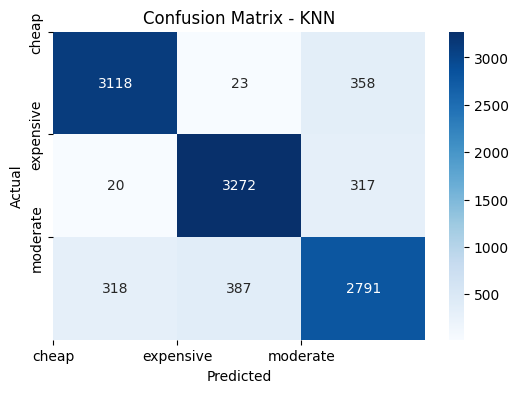

In [248]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xticks(ticks=[0,1,2], labels=le.classes_)
plt.yticks(ticks=[0,1,2], labels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN")
plt.show()


# Task 6 : Analysis and Discussion

**1 Model Comparison**:

1) Which model performed better, and what does better mean in each context?

The performance of each model depends on the evaluation metrics used for its task.

For Linear Regression, the model achieved an R² score of 0.79, with an RMSE of 4217.69 and MAE of 2557.80. In regression, a better model is one that has lower MAE and RMSE, and a higher R² value. This means the model is able to explain around 79% of the variance in car prices, which indicates a good but not perfect fit.

For KNN Classification, the model achieved a test accuracy of 0.87, along with strong precision, recall, and F1-scores across all classes. In classification, a better model means higher accuracy and balanced precision/recall, meaning it correctly classifies most of the data into the correct price categories.

Overall, the KNN classification model performed slightly better in terms of predictive performance (0.87 accuracy), while regression provides more detailed numeric predictions but with higher error.

2) Is classification easier than regression on this dataset? Why or why not?

Yes, classification is generally easier on this dataset.

This is because classification simplifies the problem by converting continuous price values into three categories (Cheap, Moderate, Expensive). This reduces complexity and makes patterns in the data easier for the model to learn.

Regression is more difficult because it tries to predict the exact price value, which is highly sensitive to noise, outliers, and small variations in the dataset. This is reflected in the relatively higher RMSE value.

Therefore, classification performs better in terms of stability and accuracy, while regression is more challenging but provides more detailed predictions.

3) Does converting price into categories lose important information?

Yes, converting price into categories does result in information loss.

When continuous values are grouped into classes, important fine-grained differences between data points are removed. For example, two cars with significantly different prices might still fall into the same category.

However, this transformation can also be beneficial because it simplifies the problem, reduces noise sensitivity, and improves model performance and interpretability.